In [1]:
import math
import re
import matplotlib.pyplot as plt

weak_passwords = ["123456", "password", "qwerty", "abc123", "111111"]

def password_strength(password):
    if password.lower() in weak_passwords:
        return "Very Weak (common password)", 0, 0, "red"

    sets = 0
    if re.search(r"[a-z]", password): sets += 26
    if re.search(r"[A-Z]", password): sets += 26
    if re.search(r"[0-9]", password): sets += 10
    if re.search(r"[^a-zA-Z0-9]", password): sets += 32

    entropy = math.log2(sets ** len(password))
    guesses = sets ** len(password)
    guesses_per_second = 1e9
    seconds = guesses / guesses_per_second

    if seconds < 60:
        time_to_crack = f"{seconds:.2f} seconds"
    elif seconds < 3600:
        time_to_crack = f"{seconds/60:.2f} minutes"
    elif seconds < 86400:
        time_to_crack = f"{seconds/3600:.2f} hours"
    elif seconds < 31536000:
        time_to_crack = f"{seconds/86400:.2f} days"
    else:
        time_to_crack = f"{seconds/31536000:.2f} years"

    if entropy < 28:
        strength, color = "Weak", "red"
    elif entropy < 36:
        strength, color = "Moderate", "orange"
    elif entropy < 60:
        strength, color = "Strong", "blue"
    else:
        strength, color = "Very Strong", "green"

    return strength, time_to_crack, entropy, color

def visualize_strength(strength, entropy, color):
    plt.bar([strength], [entropy], color=color)
    plt.title("Password Strength Visualization")
    plt.ylabel("Entropy (bits)")
    plt.show()


Strength: Very Strong
Estimated time to crack: 133347028846.36 years


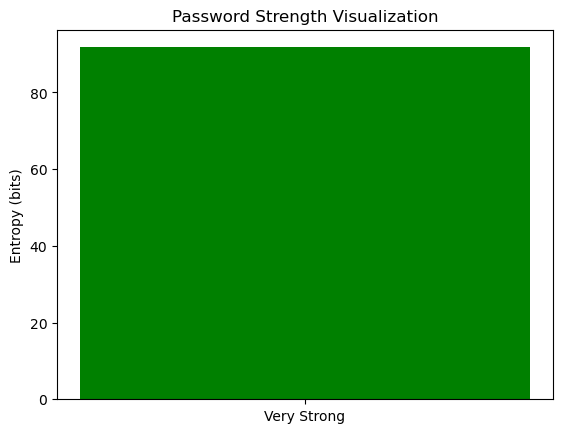

In [2]:
pwd = "MyP@ssw0rd123!"
strength, time_to_crack, entropy, color = password_strength(pwd)
print("Strength:", strength)
print("Estimated time to crack:", time_to_crack)
visualize_strength(strength, entropy, color)


Strength: Strong
Estimated time to crack: 70.55 days


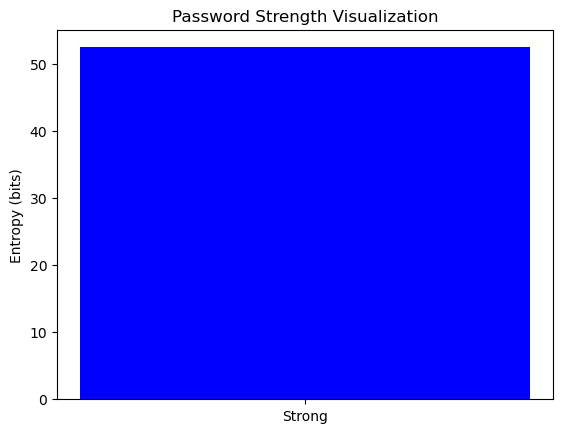

In [3]:
pwd = "Garou@69"
strength, time_to_crack, entropy, color = password_strength(pwd)
print("Strength:", strength)
print("Estimated time to crack:", time_to_crack)
visualize_strength(strength, entropy, color)
